# KAN-CLT vs Linear CLT: Side-by-Side Comparison

This notebook runs the same operations on both a KAN Cross-Layer Transcoder (KAN-CLT) and a standard linear CLT, comparing results at every step.

**What we compare:**
1. Model overview (parameter counts, architecture)
2. Reconstruction quality (MSE, cosine similarity, relative error)
3. Sparsity (active features, activation density)
4. Circuit tracing on a prompt (causal attribution)
5. Feature activation patterns
6. Monosemanticity (Gini coefficients)
7. Spline analysis — KAN-only: what nonlinear functions did it learn?
8. Optional: Shapley attribution comparison

**Requirements:**
- Trained checkpoints for both models (see `CLAUDE.md` for training commands)
- Activation dataset at `data/activations/`
- `conda activate ct` (or equivalent environment)

## 0. Configuration

Edit these paths to point to your checkpoints and data.

In [1]:
import os, sys

# ── Point to repo root ──────────────────────────────────────────────────────
REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

# ── Checkpoint paths ────────────────────────────────────────────────────────
KAN_CHECKPOINT    = "../checkpoints/gpt2_small/spline_clt_gpt2_best"
LINEAR_CHECKPOINT = "../checkpoints/gpt2_small_linear/linear_clt_gpt2_best"

# ── Data ────────────────────────────────────────────────────────────────────
DATA_DIR = "../data/activations"

# ── Evaluation settings ─────────────────────────────────────────────────────
N_EVAL_SAMPLES  = 200    # sequences for reconstruction / sparsity eval
N_MONO_FEATURES = 50     # features to analyse for monosemanticity
N_MONO_SAMPLES  = 200    # dataset sequences for monosemanticity scan
N_SPLINE_FEATURES = 6    # top KAN features to plot splines for

# ── Circuit tracing ──────────────────────────────────────────────────────────
PROMPT = "The Eiffel Tower is located in"
MAX_FEATURES = 64

# ── Shapley (slow — set RUN_SHAPLEY=True to enable) ─────────────────────────
RUN_SHAPLEY     = False
SHAPLEY_SAMPLES = 64

# ── Device / dtype ──────────────────────────────────────────────────────────
import torch
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DTYPE  = torch.float32

print(f"Device : {DEVICE}")
print(f"KAN    : {KAN_CHECKPOINT}")
print(f"Linear : {LINEAR_CHECKPOINT}")

Device : cuda
KAN    : ../checkpoints/gpt2_small/spline_clt_gpt2_best
Linear : ../checkpoints/gpt2_small_linear/linear_clt_gpt2_best


## 1. Load Both Models

In [2]:
from spline_clt.kan_transcoder import load_spline_clt
from spline_clt.utils import count_parameters, count_parameters_breakdown

models = {}

for label, ckpt in [("KAN-CLT", KAN_CHECKPOINT), ("Linear CLT", LINEAR_CHECKPOINT)]:
    if not os.path.isdir(ckpt):
        print(f"[{label}] Checkpoint not found: {ckpt!r} — skipping.")
        continue
    print(f"Loading {label} from {ckpt} …")
    m = load_spline_clt(ckpt, device=DEVICE, dtype=DTYPE)
    m.eval()
    models[label] = m
    print(f"  encoder_type={m.encoder_type}  n_layers={m.n_layers}  "
          f"d_transcoder={m.d_transcoder}  params={count_parameters(m):,}")

assert len(models) > 0, "No checkpoints loaded. Check the paths above."

# Convenience references (may be None if checkpoint missing)
kan_model    = models.get("KAN-CLT")
linear_model = models.get("Linear CLT")

Loading KAN-CLT from ../checkpoints/gpt2_small/spline_clt_gpt2_best …
  encoder_type=kan  n_layers=12  d_transcoder=4096  params=622,961,664
Loading Linear CLT from ../checkpoints/gpt2_small_linear/linear_clt_gpt2_best …
  encoder_type=linear  n_layers=12  d_transcoder=4096  params=283,223,040


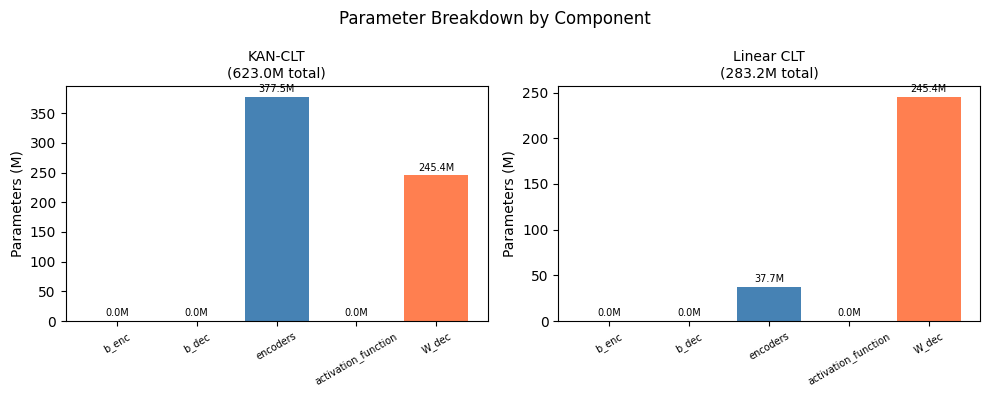

In [3]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# ── Parameter breakdown bar chart ────────────────────────────────────────────
fig, axes = plt.subplots(1, len(models), figsize=(5 * len(models), 4), sharey=False)
if len(models) == 1:
    axes = [axes]

for ax, (label, model) in zip(axes, models.items()):
    breakdown = count_parameters_breakdown(model)
    names  = list(breakdown.keys())
    values = [v / 1e6 for v in breakdown.values()]   # millions
    bars = ax.bar(names, values, color=["steelblue" if "enc" in n else "coral" for n in names])
    ax.bar_label(bars, fmt="%.1fM", padding=2, fontsize=7)
    ax.set_title(f"{label}\n({count_parameters(model)/1e6:.1f}M total)", fontsize=10)
    ax.set_ylabel("Parameters (M)")
    ax.tick_params(axis="x", rotation=30, labelsize=7)

fig.suptitle("Parameter Breakdown by Component", fontsize=12)
plt.tight_layout()
plt.show()

## 2. Load Activation Dataset

In [4]:
from spline_clt.training.data import ActivationDataset

print(f"Loading dataset from {DATA_DIR} (max_samples={N_EVAL_SAMPLES + 50}) …")
dataset = ActivationDataset.load(DATA_DIR, max_samples=N_EVAL_SAMPLES + 50)
print(f"  {len(dataset)} sequences loaded")

sample = dataset[0]
print(f"  Shape per sample: mlp_inputs={list(sample['mlp_inputs'].shape)}, "
      f"mlp_outputs={list(sample['mlp_outputs'].shape)}")
print(f"  (n_layers, seq_len, d_model)")

Loading dataset from ../data/activations (max_samples=250) …
  250 sequences loaded
  Shape per sample: mlp_inputs=[12, 128, 768], mlp_outputs=[12, 128, 768]
  (n_layers, seq_len, d_model)


## 3. Reconstruction Quality

How well does each model approximate the original MLP outputs?

| Metric | Ideal |
|--------|-------|
| MSE (total) | < 0.005 |
| Cosine similarity | > 0.95 |
| Relative error | < 0.05 |

In [5]:
# Import the evaluate_model function directly from compare_models.py
sys.path.insert(0, os.path.join(REPO_ROOT, "experiments"))
from compare_models import evaluate_model

recon_metrics = {}
for label, model in models.items():
    print(f"Evaluating {label} on {N_EVAL_SAMPLES} samples …")
    m = evaluate_model(model, dataset, DEVICE, DTYPE, n_samples=N_EVAL_SAMPLES)
    recon_metrics[label] = m
    print(f"  MSE={m['mse_total']:.6f}  cos_sim={m['cosine_similarity']:.4f}  "
          f"rel_err={m['relative_error']:.4f}")

print("Done.")

Evaluating KAN-CLT on 200 samples …


  MSE=2.072871  cos_sim=0.1483  rel_err=0.5434
Evaluating Linear CLT on 200 samples …


  MSE=3.691395  cos_sim=0.0924  rel_err=0.7256
Done.


In [6]:
# ── Summary table ─────────────────────────────────────────────────────────────
metric_labels = [
    ("MSE (total)",           "mse_total",          6),
    ("Cosine similarity",     "cosine_similarity",  4),
    ("Relative error",        "relative_error",     4),
    ("Active features / pos", "active_per_pos",     2),
    ("Activation density",    "activation_density", 6),
    ("Parameters",            "n_params",           0),
]

col_w = 16
labels = list(recon_metrics.keys())
header = f"{'Metric':<28}" + "".join(f"{l:>{col_w}}" for l in labels)
if len(labels) == 2:
    header += f"{'Δ (KAN−Lin)':>{col_w}}"
print("\n" + "=" * len(header))
print(header)
print("=" * len(header))

for name, key, dec in metric_labels:
    vals = [recon_metrics[l][key] for l in labels]
    if key == "n_params":
        row = f"{name:<28}" + "".join(f"{v:>{col_w},}" for v in vals)
        if len(vals) == 2:
            row += f"{vals[0]-vals[1]:>+{col_w},}"
    else:
        row = f"{name:<28}" + "".join(f"{v:>{col_w}.{dec}f}" for v in vals)
        if len(vals) == 2:
            row += f"{vals[0]-vals[1]:>+{col_w}.{dec}f}"
    print(row)
print("=" * len(header))


Metric                               KAN-CLT      Linear CLT     Δ (KAN−Lin)
MSE (total)                         2.072871        3.691395       -1.618524
Cosine similarity                     0.1483          0.0924         +0.0559
Relative error                        0.5434          0.7256         -0.1822
Active features / pos                  10.83           60.60          -49.78
Activation density                  0.002643        0.014795       -0.012152
Parameters                       622,961,664     283,223,040    +339,738,624


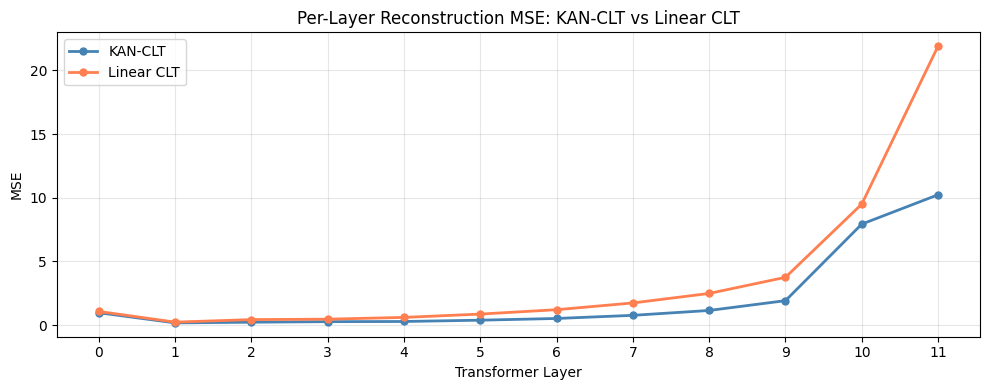

In [7]:
# ── Per-layer MSE plot ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))

colors = {"KAN-CLT": "steelblue", "Linear CLT": "coral"}
n_layers = None

for label, m in recon_metrics.items():
    mse = m["mse_per_layer"]
    n_layers = len(mse)
    ax.plot(range(n_layers), mse, marker="o", label=label,
            color=colors.get(label), linewidth=2, markersize=5)

ax.set_xlabel("Transformer Layer")
ax.set_ylabel("MSE")
ax.set_title("Per-Layer Reconstruction MSE: KAN-CLT vs Linear CLT")
ax.set_xticks(range(n_layers or 12))
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Sparsity Comparison

How many features does each model activate per token position?

In [8]:
# Collect per-sample active-feature counts for both models
active_counts = {label: [] for label in models}

n_sparsity_samples = min(50, len(dataset))
indices = torch.randperm(len(dataset))[:n_sparsity_samples]

with torch.no_grad():
    for idx in indices:
        sample = dataset[int(idx)]
        x_in = sample["mlp_inputs"].to(device=DEVICE, dtype=DTYPE)
        for label, model in models.items():
            acts = model.encode(x_in)           # (n_layers, seq, d_transcoder)
            # active features per (layer, position)
            per_pos = (acts > 0).float().sum(dim=-1).mean().item()
            active_counts[label].append(per_pos)

print("Mean active features per position:")
for label, counts in active_counts.items():
    print(f"  {label:<14}: {np.mean(counts):.1f}  (std {np.std(counts):.1f})")

Mean active features per position:
  KAN-CLT       : 10.8  (std 0.0)
  Linear CLT    : 61.3  (std 7.6)


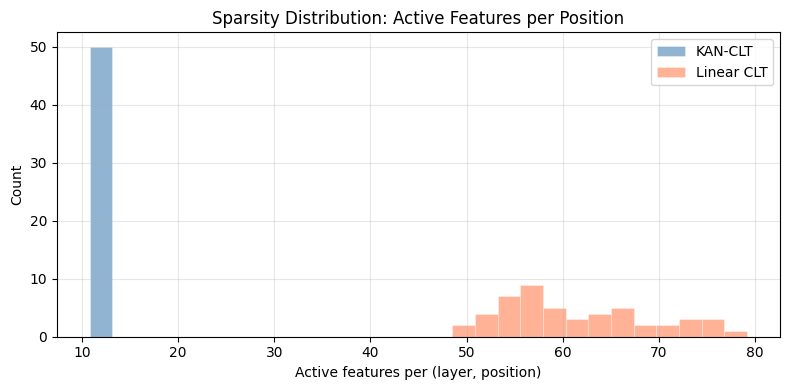

In [9]:
# ── Sparsity distribution plot ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))

bins = np.linspace(
    min(min(v) for v in active_counts.values()),
    max(max(v) for v in active_counts.values()),
    30,
)

for label, counts in active_counts.items():
    ax.hist(counts, bins=bins, alpha=0.6, label=label,
            color=colors.get(label), edgecolor="white", linewidth=0.4)

ax.set_xlabel("Active features per (layer, position)")
ax.set_ylabel("Count")
ax.set_title("Sparsity Distribution: Active Features per Position")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Circuit Tracing on a Prompt

Run causal ablation attribution on both models for the same prompt and compare:
- Which features are most active?
- How do the attribution graphs differ?

In [10]:
# Collect activations for the prompt (reusable for both models)
sys.path.insert(0, os.path.join(REPO_ROOT, "experiments"))
from run_circuit import collect_activations_for_prompt

# Use the first loaded model's config for hook names
first_model = next(iter(models.values()))

print(f"Prompt: {PROMPT!r}")
mlp_inputs, mlp_outputs, tokens = collect_activations_for_prompt(
    model_name="gpt2",
    prompt=PROMPT,
    n_layers=first_model.n_layers,
    device=DEVICE,
    feature_input_hook=first_model.feature_input_hook,
    feature_output_hook=first_model.feature_output_hook,
)
mlp_inputs  = mlp_inputs.to(dtype=DTYPE)
mlp_outputs = mlp_outputs.to(dtype=DTYPE)

print(f"Tokens ({len(tokens)}): {tokens}")
print(f"Activation shape: {list(mlp_inputs.shape)}  (n_layers, seq_len, d_model)")

Prompt: 'The Eiffel Tower is located in'
Loading gpt2 with TransformerLens...


`torch_dtype` is deprecated! Use `dtype` instead!


Loaded pretrained model gpt2 into HookedTransformer
Running forward pass: 9 tokens...
Tokens (9): ['<|endoftext|>', 'The', ' E', 'iff', 'el', ' Tower', ' is', ' located', ' in']
Activation shape: [12, 9, 768]  (n_layers, seq_len, d_model)


In [11]:
from attribution.causal import build_attribution_graph

attributions = {}
for label, model in models.items():
    print(f"Running causal attribution for {label} (max_features={MAX_FEATURES}) …")
    with torch.no_grad():
        attr = build_attribution_graph(model, mlp_inputs, max_features=MAX_FEATURES)
    attributions[label] = attr
    n_active = len(attr["active_features"])
    print(f"  {n_active} active features found")

print("Done.")

Running causal attribution for KAN-CLT (max_features=64) …


Ablating features: 100%|██████████| 64/64 [00:00<00:00, 83.30it/s]


  64 active features found
Running causal attribution for Linear CLT (max_features=64) …


Ablating features: 100%|██████████| 64/64 [00:00<00:00, 73.80it/s]


  64 active features found
Done.


In [12]:
# ── Feature table: top 15 features for each model ────────────────────────────
TOP_K = 15

for label, attr in attributions.items():
    active = attr["active_features"]   # (n_active, 3): layer, pos, feat_idx
    values = attr["activation_values"] # (n_active,)
    sorted_idx = values.abs().argsort(descending=True)

    print(f"\n{'─'*58}")
    print(f"  {label}  —  top {TOP_K} features by activation")
    print(f"{'─'*58}")
    print(f"  {'Rank':<5} {'Layer':<6} {'Pos':<5} {'FeatIdx':<9} {'Activation':>12} {'Token':>10}")
    print(f"  {'─'*53}")
    for rank in range(min(TOP_K, len(sorted_idx))):
        i   = sorted_idx[rank].item()
        layer, pos, feat = active[i, 0].item(), active[i, 1].item(), active[i, 2].item()
        tok = tokens[pos] if pos < len(tokens) else "?"
        print(f"  {rank+1:<5} {layer:<6} {pos:<5} {feat:<9} {values[i].item():>12.4f} {tok!r:>10}")


──────────────────────────────────────────────────────────
  KAN-CLT  —  top 15 features by activation
──────────────────────────────────────────────────────────
  Rank  Layer  Pos   FeatIdx     Activation      Token
  ─────────────────────────────────────────────────────
  1     9      0     2601          158.1246 '<|endoftext|>'
  2     8      0     2882          154.6630 '<|endoftext|>'
  3     10     0     4047          149.5603 '<|endoftext|>'
  4     6      0     704           148.3940 '<|endoftext|>'
  5     6      0     1962          148.2886 '<|endoftext|>'
  6     10     0     2002          147.7419 '<|endoftext|>'
  7     8      0     3589          147.1830 '<|endoftext|>'
  8     6      0     30            146.2878 '<|endoftext|>'
  9     9      0     3966          145.3710 '<|endoftext|>'
  10    6      0     3230          144.5007 '<|endoftext|>'
  11    10     0     3459          144.2453 '<|endoftext|>'
  12    9      0     4081          142.6130 '<|endoftext|>'
  13  

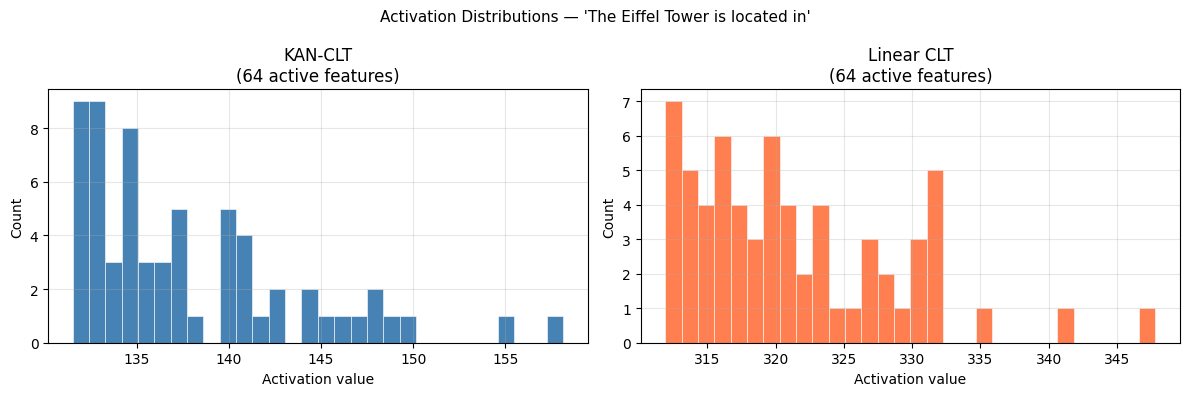

In [13]:
# ── Activation value distribution per model ──────────────────────────────────
fig, axes = plt.subplots(1, len(attributions), figsize=(6 * len(attributions), 4), sharey=False)
if len(attributions) == 1:
    axes = [axes]

for ax, (label, attr) in zip(axes, attributions.items()):
    vals = attr["activation_values"].cpu().numpy()
    ax.hist(vals, bins=30, color=colors.get(label, "grey"), edgecolor="white", linewidth=0.4)
    ax.set_title(f"{label}\n({len(vals)} active features)")
    ax.set_xlabel("Activation value")
    ax.set_ylabel("Count")
    ax.grid(alpha=0.3)

fig.suptitle(f"Activation Distributions — {PROMPT!r}", fontsize=11)
plt.tight_layout()
plt.show()

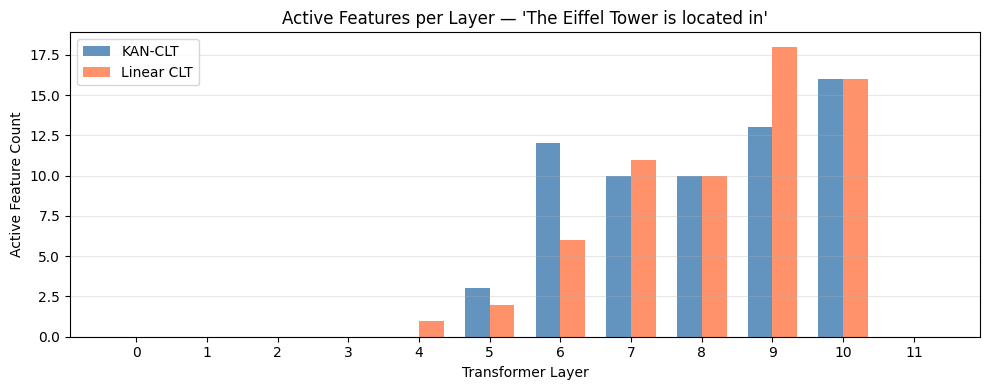

In [14]:
# ── Features by layer: where does each model "look"? ─────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
n_layers = first_model.n_layers

x = np.arange(n_layers)
bar_width = 0.35
offsets = np.linspace(-(len(attributions)-1)*bar_width/2,
                       (len(attributions)-1)*bar_width/2,
                       len(attributions))

for offset, (label, attr) in zip(offsets, attributions.items()):
    layers = attr["active_features"][:, 0].cpu().numpy()
    counts = np.bincount(layers, minlength=n_layers)
    ax.bar(x + offset, counts, width=bar_width, label=label,
           color=colors.get(label), alpha=0.85)

ax.set_xlabel("Transformer Layer")
ax.set_ylabel("Active Feature Count")
ax.set_title(f"Active Features per Layer — {PROMPT!r}")
ax.set_xticks(x)
ax.legend()
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

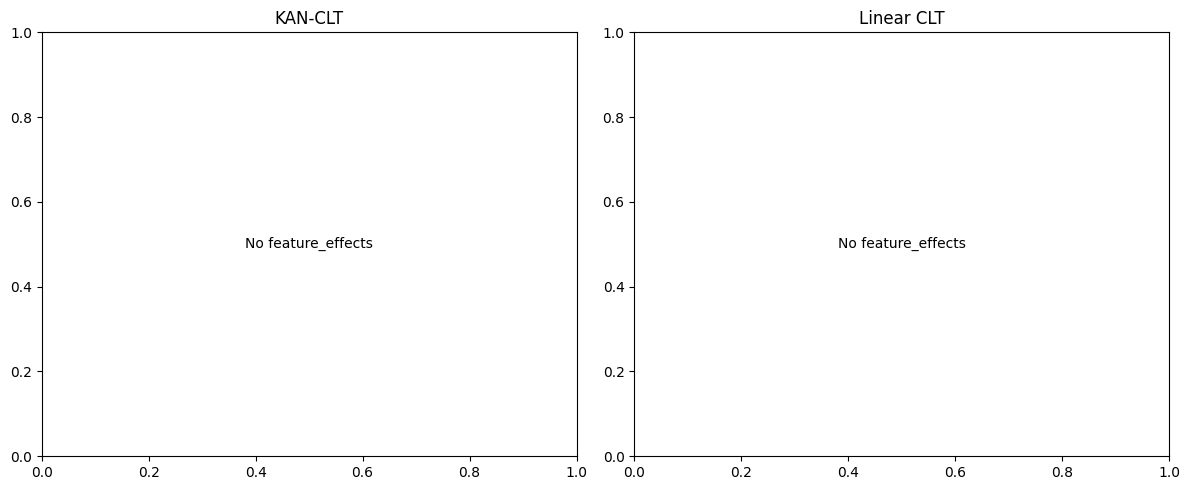

In [15]:
# ── Feature-to-feature effect heatmap ────────────────────────────────────────
# Show the top-25 × top-25 causal effect matrix for each model
TOP_HEAT = 25

fig, axes = plt.subplots(1, len(attributions), figsize=(6 * len(attributions), 5))
if len(attributions) == 1:
    axes = [axes]

for ax, (label, attr) in zip(axes, attributions.items()):
    effects = attr.get("feature_effects")
    if effects is None:
        ax.text(0.5, 0.5, "No feature_effects", ha="center", va="center",
                transform=ax.transAxes)
        ax.set_title(label)
        continue

    # Take top-K by activation
    n = min(TOP_HEAT, effects.shape[0])
    top_idx = attr["activation_values"].abs().argsort(descending=True)[:n]
    sub = effects[top_idx][:, top_idx].cpu().numpy()

    vmax = np.abs(sub).max() or 1.0
    im = ax.imshow(sub, cmap="RdBu_r", vmin=-vmax, vmax=vmax, aspect="auto")
    fig.colorbar(im, ax=ax, shrink=0.8)
    ax.set_title(f"{label}\nFeature-to-Feature Causal Effects (top {n})")
    ax.set_xlabel("Target feature (rank)")
    ax.set_ylabel("Source feature (rank)")

plt.tight_layout()
plt.show()

## 6. Monosemanticity: Gini Coefficients

Higher Gini = more selective feature (activates on fewer, more specific examples).
A feature with Gini > 0.8 is a good candidate for manual interpretability inspection.

In [16]:
from eval.monosemanticity import collect_max_activating_examples, gini_coefficient

mono_reports = {}
for label, model in models.items():
    print(f"Analysing monosemanticity for {label} "
          f"(top {N_MONO_FEATURES} features, {N_MONO_SAMPLES} samples) …")
    reports = collect_max_activating_examples(
        model, dataset,
        top_n_features=N_MONO_FEATURES,
        top_k_examples=5,
        n_samples=N_MONO_SAMPLES,
        device=DEVICE,
        dtype=DTYPE,
    )
    mono_reports[label] = reports
    ginis = [r.gini_coefficient for r in reports]
    high  = sum(1 for g in ginis if g > 0.8)
    print(f"  mean Gini={np.mean(ginis):.3f}  "
          f"median={np.median(ginis):.3f}  "
          f"features with Gini>0.8: {high}/{len(ginis)}")

print("Done.")

Analysing monosemanticity for KAN-CLT (top 50 features, 200 samples) …
Pass 1: computing activation frequencies over 200 samples...


Frequency scan: 100%|██████████| 200/200 [00:05<00:00, 36.13it/s]


Pass 2: collecting top-5 max-activating examples for each feature...


Example collection: 100%|██████████| 200/200 [00:03<00:00, 55.05it/s]


  mean Gini=0.014  median=0.013  features with Gini>0.8: 0/50
Analysing monosemanticity for Linear CLT (top 50 features, 200 samples) …
Pass 1: computing activation frequencies over 200 samples...


Frequency scan: 100%|██████████| 200/200 [00:03<00:00, 55.68it/s]


Pass 2: collecting top-5 max-activating examples for each feature...


Example collection: 100%|██████████| 200/200 [00:02<00:00, 85.43it/s]


  mean Gini=0.125  median=0.123  features with Gini>0.8: 0/50
Done.


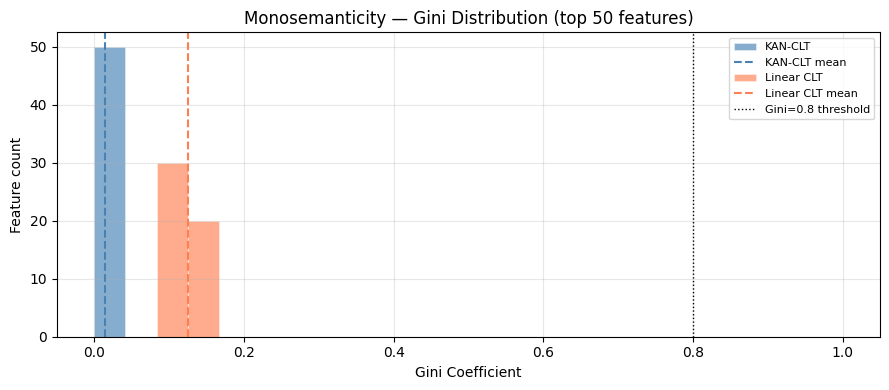

In [17]:
# ── Gini distribution plot ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))

bins = np.linspace(0, 1, 25)
for label, reports in mono_reports.items():
    ginis = [r.gini_coefficient for r in reports]
    ax.hist(ginis, bins=bins, alpha=0.65, label=label,
            color=colors.get(label), edgecolor="white", linewidth=0.4)
    ax.axvline(np.mean(ginis), linestyle="--", color=colors.get(label),
               linewidth=1.5, label=f"{label} mean")

ax.axvline(0.8, color="black", linewidth=1, linestyle=":", label="Gini=0.8 threshold")
ax.set_xlabel("Gini Coefficient")
ax.set_ylabel("Feature count")
ax.set_title(f"Monosemanticity — Gini Distribution (top {N_MONO_FEATURES} features)")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [18]:
# ── Top 10 most monosemantic features per model ──────────────────────────────
for label, reports in mono_reports.items():
    top10 = sorted(reports, key=lambda r: r.gini_coefficient, reverse=True)[:10]
    print(f"\n{label} — top 10 features by Gini coefficient")
    print(f"  {'Layer':<6} {'FeatIdx':<9} {'Gini':>6} {'Freq':>7} {'MaxAct':>9}")
    print(f"  {'─'*42}")
    for r in top10:
        print(f"  {r.layer:<6} {r.feature_id:<9} {r.gini_coefficient:>6.3f} "
              f"{r.activation_frequency:>7.4f} {r.max_activation:>9.4f}")


KAN-CLT — top 10 features by Gini coefficient
  Layer  FeatIdx     Gini    Freq    MaxAct
  ──────────────────────────────────────────
  1      131        0.024  0.0079   25.1796
  1      3161       0.024  0.0079   23.7035
  1      3727       0.024  0.0079   23.6947
  1      2786       0.023  0.0079   12.0180
  1      1589       0.023  0.0079   15.5812
  1      3824       0.022  0.0079   31.5137
  1      3324       0.022  0.0079   21.6754
  1      717        0.021  0.0079   17.6014
  1      3149       0.020  0.0079   26.6280
  1      297        0.020  0.0079   27.8175

Linear CLT — top 10 features by Gini coefficient
  Layer  FeatIdx     Gini    Freq    MaxAct
  ──────────────────────────────────────────
  11     2367       0.161  0.9996   49.4350
  11     272        0.144  0.9997   63.9991
  11     3577       0.143  0.9995   73.6307
  11     3908       0.143  0.9994   71.6626
  11     2676       0.138  0.9995   66.6518
  11     816        0.137  0.9997   66.1304
  11     2568       0

## 7. Spline Analysis (KAN-CLT Only)

The KAN encoder learns B-spline transfer functions for each (feature, input dimension) pair.
Plotting these reveals what nonlinear patterns it has learned.

**Shape interpretation:**
- **Straight line** → behaves like a linear encoder; no KAN benefit
- **Step / threshold** → detects when input crosses a value; nonlinear boundary
- **Peak / bump** → responds to a specific input range (band-pass)
- **Polynomial curve** → smooth nonlinearity a linear encoder cannot capture

In [19]:
from experiments.analyze_splines import (
    collect_feature_stats,
    extract_spline_curve,
    top_input_dims,
)

if kan_model is None:
    print("KAN-CLT not loaded — skipping spline analysis.")
elif kan_model.encoder_type != "kan":
    print(f"encoder_type={kan_model.encoder_type!r} — spline analysis requires KAN encoder.")
else:
    print("Collecting KAN feature statistics …")
    spline_stats = collect_feature_stats(
        kan_model, dataset, DEVICE, torch.float32, n_samples=min(200, len(dataset))
    )
    freq = spline_stats["activation_frequency"]  # (n_layers, d_transcoder)

    # Top features by activation frequency across all layers
    flat_freq  = freq.reshape(-1)
    top_indices = flat_freq.topk(N_SPLINE_FEATURES).indices
    top_features = [
        (int(idx // kan_model.d_transcoder), int(idx % kan_model.d_transcoder))
        for idx in top_indices
    ]
    print(f"Top {N_SPLINE_FEATURES} features: {top_features}")

Top 6 features: [(1, 3149), (1, 717), (1, 521), (1, 297), (1, 809), (1, 131)]


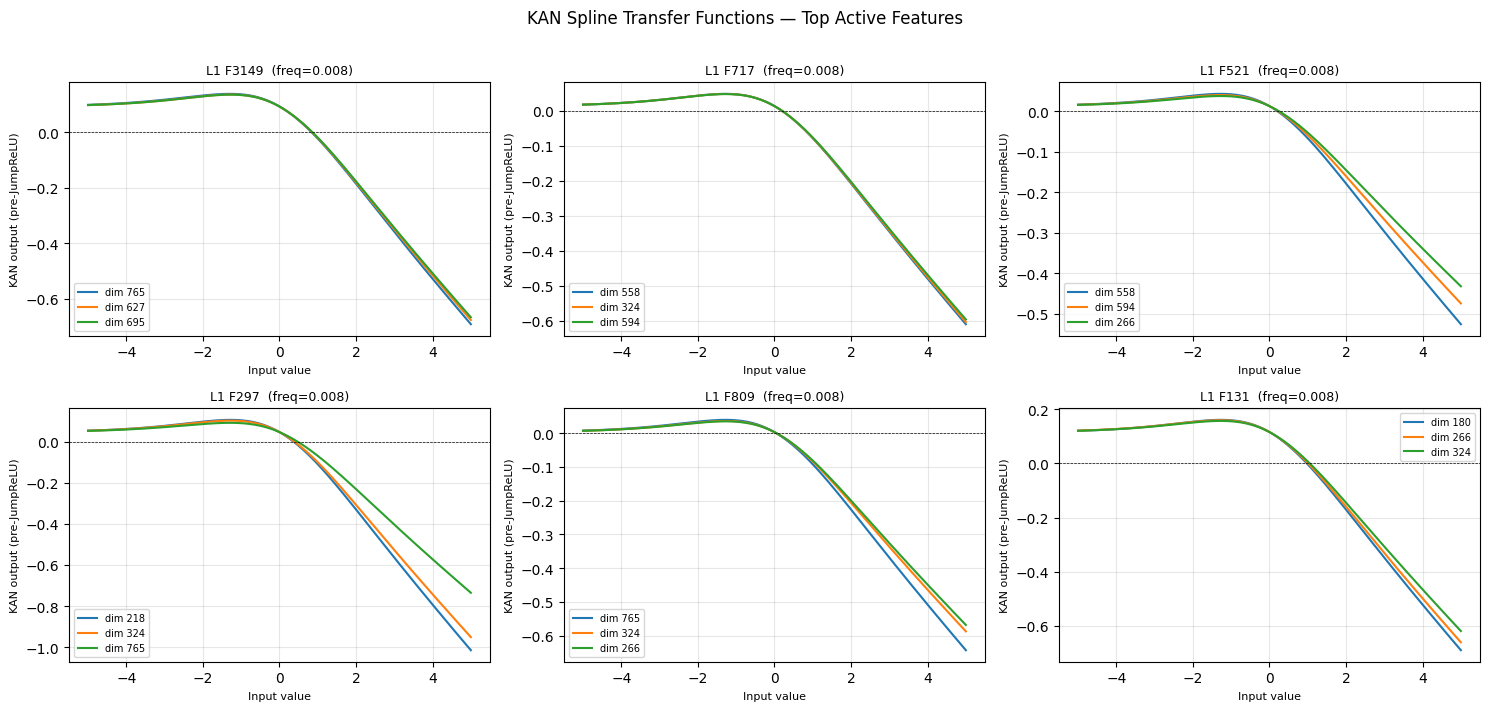

In [20]:
if kan_model is not None and kan_model.encoder_type == "kan":
    TOP_DIMS = 3  # input dimensions to plot per feature

    n_cols = 3
    n_rows = int(np.ceil(N_SPLINE_FEATURES / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(5 * n_cols, 3.5 * n_rows),
                             squeeze=False)

    for plot_idx, (layer_id, feature_id) in enumerate(top_features):
        ax = axes[plot_idx // n_cols][plot_idx % n_cols]
        f_freq = freq[layer_id, feature_id].item()

        try:
            dims = top_input_dims(kan_model, layer_id, feature_id, top_k=TOP_DIMS)
            for dim in dims:
                t_vals, curve = extract_spline_curve(
                    kan_model, layer_id, feature_id, dim, device=DEVICE
                )
                ax.plot(t_vals, curve, label=f"dim {dim}", linewidth=1.5)
            ax.axhline(0, color="k", linewidth=0.5, linestyle="--")
            ax.set_title(f"L{layer_id} F{feature_id}  (freq={f_freq:.3f})", fontsize=9)
            ax.set_xlabel("Input value", fontsize=8)
            ax.set_ylabel("KAN output (pre-JumpReLU)", fontsize=8)
            ax.legend(fontsize=7)
            ax.grid(alpha=0.3)
        except Exception as e:
            ax.text(0.5, 0.5, str(e), ha="center", va="center",
                    transform=ax.transAxes, fontsize=8, color="red")
            ax.set_title(f"L{layer_id} F{feature_id}", fontsize=9)

    # Hide unused subplots
    for i in range(N_SPLINE_FEATURES, n_rows * n_cols):
        axes[i // n_cols][i % n_cols].set_visible(False)

    fig.suptitle("KAN Spline Transfer Functions — Top Active Features",
                 fontsize=12, y=1.01)
    plt.tight_layout()
    plt.show()

### Linearity Check: How linear are the KAN splines?

Fit a line to each spline curve and measure the residual. Low residual = nearly linear (no KAN benefit for that feature). High residual = the KAN learned a genuinely nonlinear function.

In [21]:
if kan_model is not None and kan_model.encoder_type == "kan":
    nonlinearity_scores = []

    for layer_id, feature_id in top_features:
        try:
            dims = top_input_dims(kan_model, layer_id, feature_id, top_k=1)
            t_vals, curve = extract_spline_curve(
                kan_model, layer_id, feature_id, dims[0], n_points=200, device=DEVICE
            )
            # Fit linear and measure R² deviation
            coeffs = np.polyfit(t_vals, curve, 1)
            linear_fit = np.polyval(coeffs, t_vals)
            residual = np.mean((curve - linear_fit) ** 2)
            signal   = np.var(curve)
            nonlin   = residual / (signal + 1e-8)  # fraction unexplained by linear fit
            nonlinearity_scores.append((layer_id, feature_id, nonlin))
        except Exception:
            continue

    nonlinearity_scores.sort(key=lambda x: x[2], reverse=True)

    print("Nonlinearity scores (residual / variance, higher = more nonlinear):")
    print(f"  {'Layer':<6} {'Feature':<9} {'Nonlinearity':>14}")
    print(f"  {'─'*32}")
    for layer_id, feature_id, score in nonlinearity_scores:
        tag = "  ← nonlinear" if score > 0.05 else ""
        print(f"  {layer_id:<6} {feature_id:<9} {score:>14.4f}{tag}")

Nonlinearity scores (residual / variance, higher = more nonlinear):
  Layer  Feature     Nonlinearity
  ────────────────────────────────
  1      131               0.2265  ← nonlinear
  1      297               0.2261  ← nonlinear
  1      717               0.2260  ← nonlinear
  1      521               0.2260  ← nonlinear
  1      809               0.2258  ← nonlinear
  1      3149              0.2250  ← nonlinear


## 8. Shapley Attribution (Optional — Slow)

Shapley values give game-theoretically fair credit to each feature, correctly handling nonlinear interactions. This is O(n_features × n_samples) decoder evaluations.

Set `RUN_SHAPLEY = True` in the configuration cell to enable this section.

In [22]:
if not RUN_SHAPLEY:
    print("Skipping Shapley attribution (RUN_SHAPLEY=False).")
    print("Set RUN_SHAPLEY=True in the configuration cell to run this section.")

Skipping Shapley attribution (RUN_SHAPLEY=False).
Set RUN_SHAPLEY=True in the configuration cell to run this section.


In [23]:
if RUN_SHAPLEY:
    from attribution.shapley import shapley_attribution

    shapley_results = {}
    for label, model in models.items():
        print(f"Running Shapley for {label} "
              f"(samples={SHAPLEY_SAMPLES}, max_features={min(MAX_FEATURES,32)}) …")
        with torch.no_grad():
            shap = shapley_attribution(
                model, mlp_inputs,
                target="reconstruction",
                n_samples=SHAPLEY_SAMPLES,
                max_features=min(MAX_FEATURES, 32),
                antithetic=True,
            )
        shapley_results[label] = shap
        total = shap["shapley_values"].sum().item()
        print(f"  Sum of Shapley values = {total:.4f}  "
              f"(= reconstruction improvement over empty baseline)")

    print("Done.")

In [24]:
if RUN_SHAPLEY and shapley_results:
    fig, axes = plt.subplots(1, len(shapley_results),
                             figsize=(7 * len(shapley_results), 5),
                             sharey=False)
    if len(shapley_results) == 1:
        axes = [axes]

    for ax, (label, shap) in zip(axes, shapley_results.items()):
        sv     = shap["shapley_values"].cpu().numpy()
        active = shap["active_features"].cpu().numpy()  # (n_active, 3)
        sorted_idx = np.argsort(sv)[::-1][:20]          # top 20

        top_sv     = sv[sorted_idx]
        top_labels = [f"L{active[i,0]}F{active[i,2]}@p{active[i,1]}"
                      for i in sorted_idx]

        bar_colors = ["steelblue" if v >= 0 else "coral" for v in top_sv]
        ax.barh(range(len(top_sv)), top_sv[::-1], color=bar_colors[::-1])
        ax.set_yticks(range(len(top_sv)))
        ax.set_yticklabels(top_labels[::-1], fontsize=7)
        ax.axvline(0, color="black", linewidth=0.8)
        ax.set_xlabel("Shapley value (reconstruction MSE reduction)")
        ax.set_title(f"{label}\nTop-20 Features by Shapley Value")
        ax.grid(alpha=0.3, axis="x")

    plt.tight_layout()
    plt.show()

In [25]:
if RUN_SHAPLEY and len(shapley_results) == 2:
    # Compare Shapley vs causal rank agreement for both models
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    for ax, (label, shap) in zip(axes, shapley_results.items()):
        sv     = shap["shapley_values"].cpu().numpy()
        causal = attributions[label]["activation_values"].cpu().numpy()
        n      = min(len(sv), len(causal))

        ax.scatter(causal[:n], sv[:n], alpha=0.5, s=20,
                   color=colors.get(label, "grey"))
        ax.set_xlabel("Activation value (causal)")
        ax.set_ylabel("Shapley value")
        ax.set_title(f"{label}\nCausal Activation vs Shapley Value")
        ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

## 9. Summary Table

In [ ]:
print("\n" + "═" * 70)
print("  KAN-CLT vs Linear CLT — Summary".center(70))
print("═" * 70)

summary_rows = []

# Reconstruction
if recon_metrics:
    summary_rows.append(("── Reconstruction ──────────────────────────────", None, None))
    for name, key, fmt_str in [
        ("MSE (total)",        "mse_total",         ".6f"),
        ("Cosine similarity",  "cosine_similarity", ".4f"),
        ("Relative error",     "relative_error",    ".4f"),
    ]:
        vals = {l: recon_metrics[l][key] for l in recon_metrics}
        summary_rows.append((name, vals, fmt_str))

# Sparsity
if recon_metrics:
    summary_rows.append(("── Sparsity ─────────────────────────────────────", None, None))
    for name, key, fmt_str in [
        ("Active features / pos", "active_per_pos",     ".2f"),
        ("Activation density",    "activation_density", ".4f"),
        ("Parameters",            "n_params",           ","),
    ]:
        vals = {l: recon_metrics[l][key] for l in recon_metrics}
        summary_rows.append((name, vals, fmt_str))

# Circuit tracing
summary_rows.append(("── Circuit Tracing ──────────────────────────────", None, None))
vals = {l: len(attributions[l]["active_features"]) for l in attributions}
summary_rows.append((f"Active features ('{PROMPT[:25]}…')", vals, ","))

# Monosemanticity
if mono_reports:
    summary_rows.append(("── Monosemanticity ──────────────────────────────", None, None))
    gini_means = {l: np.mean([r.gini_coefficient for r in mono_reports[l]])
                  for l in mono_reports}
    summary_rows.append(("Mean Gini coefficient", gini_means, ".3f"))
    high_gini = {l: sum(1 for r in mono_reports[l] if r.gini_coefficient > 0.8)
                 for l in mono_reports}
    summary_rows.append((f"Features with Gini > 0.8  (of {N_MONO_FEATURES})", high_gini, ","))

# Print
labels = list(models.keys())
col_w = 16
hdr = f"  {'Metric':<46}" + "".join(f"{l:>{col_w}}" for l in labels)
print(hdr)
print("  " + "─" * (len(hdr) - 2))

for name, vals, fmt_str in summary_rows:
    if vals is None:
        print(f"\n  {name}")
        continue
    row = f"  {name:<46}"
    for l in labels:
        v = vals.get(l, float("nan"))
        try:
            row += f"{format(v, fmt_str):>{col_w}}"
        except (ValueError, TypeError):
            row += f"{'N/A':>{col_w}}"
    print(row)

print("\n" + "═" * 70)


══════════════════════════════════════════════════════════════════════
                    KAN-CLT vs Linear CLT — Summary                   
══════════════════════════════════════════════════════════════════════
  Metric                                                 KAN-CLT      Linear CLT
  ──────────────────────────────────────────────────────────────────────────────

  ── Reconstruction ──────────────────────────────
  MSE (total)                                           2.072871        3.691395
  Cosine similarity                                       0.1483          0.0924
  Relative error                                          0.5434          0.7256

  ── Sparsity ─────────────────────────────────────
  Active features / pos                                    10.83           60.60
  Activation density                                      0.0026          0.0148
  Parameters                                         622,961,664     283,223,040

  ── Circuit Tracing ───────────